# Assignment 15: Clustering Analysis (K-Means & DBSCAN)

**Name:** Ahmad Ali  
**Batch:** Data Science Weekday – Hyderabad  
**Topic:** Customer Segmentation using Clustering

## Importing Libraries

We import essential libraries:

- pandas, numpy → data handling  
- matplotlib, seaborn → visualization  
- StandardScaler → feature scaling  
- KMeans, DBSCAN → clustering algorithms  
- silhouette_score → evaluation metric  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

## Loading the Dataset

In this step, we load the East-West Airlines dataset. The dataset contains customer information such as flight activity, reward miles, and credit card usage.

This data will be used to identify customer segments using clustering techniques.

In [ ]:
df = pd.read_excel("C:/Users/Ali/Downloads/EastWestAirlines.xlsx", sheet_name=1)
df.head(20)

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
5,6,16420,0,1,1,1,0,0,0,0,6942,0
6,7,84914,0,3,1,1,27482,25,0,0,6994,0
7,8,20856,0,1,1,1,5250,4,250,1,6938,1
8,9,443003,0,3,2,1,1753,43,3850,12,6948,1
9,10,104860,0,3,1,1,28426,28,1150,3,6931,1


## Data Cleaning

The 'ID#' column is a unique identifier and does not contribute to clustering. Since clustering depends on feature similarity, we remove this column.

In [ ]:
df.drop("ID#", axis=1, inplace=True)

## Data Understanding

We analyze the dataset structure to ensure it is suitable for clustering:

- `info()` → checks data types  
- `describe()` → statistical summary  
- `isnull()` → missing values  

This step ensures the dataset is clean and numerical.

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Balance            3999 non-null   int64
 1   Qual_miles         3999 non-null   int64
 2   cc1_miles          3999 non-null   int64
 3   cc2_miles          3999 non-null   int64
 4   cc3_miles          3999 non-null   int64
 5   Bonus_miles        3999 non-null   int64
 6   Bonus_trans        3999 non-null   int64
 7   Flight_miles_12mo  3999 non-null   int64
 8   Flight_trans_12    3999 non-null   int64
 9   Days_since_enroll  3999 non-null   int64
 10  Award?             3999 non-null   int64
dtypes: int64(11)
memory usage: 343.8 KB


Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

## Exploratory Data Analysis

EDA helps us understand:

- Distribution of each feature (histograms)
- Presence of outliers (box plots)

Outliers are important because clustering algorithms are sensitive to extreme values.

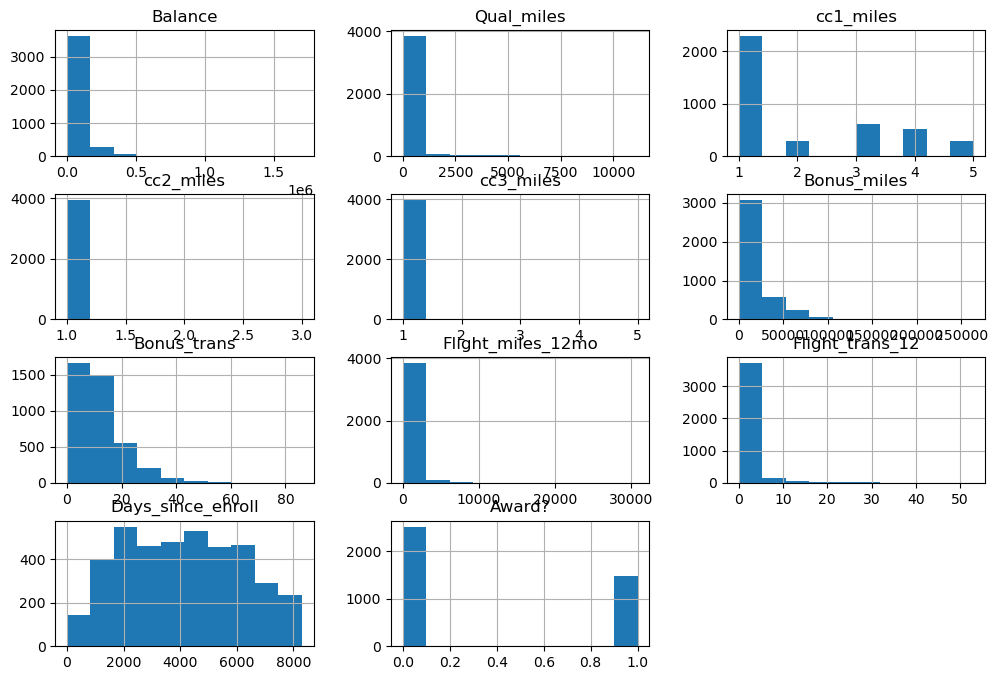

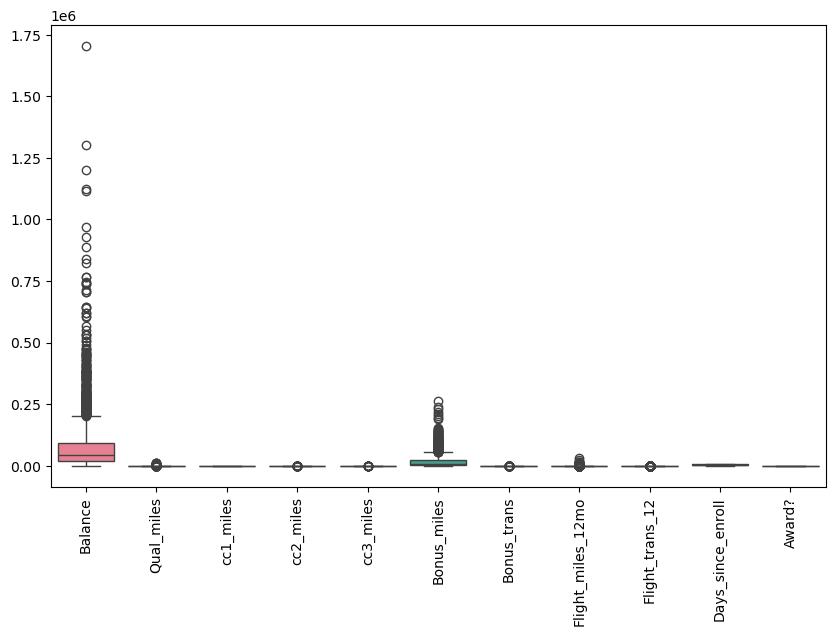

In [ ]:
df.hist(figsize=(12,8))
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

## Feature Scaling

Clustering algorithms like K-Means and DBSCAN rely on distance calculations.

If features are on different scales (e.g., Balance vs Bonus_miles), larger values dominate the result.

StandardScaler transforms data to:
- Mean = 0
- Standard deviation = 1

This ensures all features contribute equally.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## PCA (Dimensionality Reduction)

We apply PCA to reduce high-dimensional data into 2 components.

This helps in:
- Visualizing clusters clearly
- Reducing noise and redundancy
- Improving clustering performance

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

## K-Means on PCA Data

We apply K-Means on PCA-transformed data to improve clustering performance and visualization.

In [ ]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)

## PCA Cluster Visualization

We visualize clusters in 2D using PCA components.

This helps clearly observe separation between clusters.

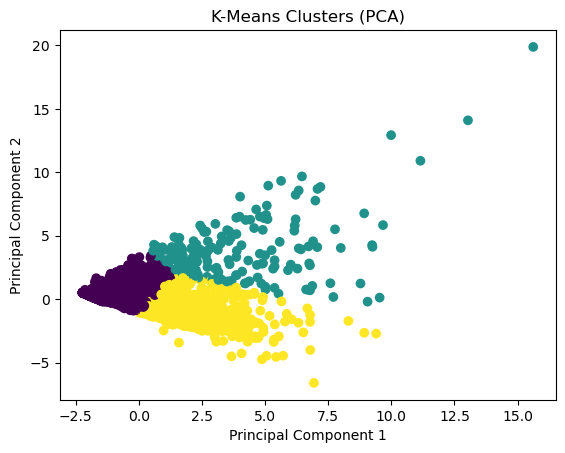

In [ ]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca, cmap='viridis')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA)")
plt.show()

## Advanced Insight (PCA vs Original)

Clustering on PCA-transformed data provides better visualization and may improve cluster separation by removing redundant features.

While original data retains full information, PCA simplifies the dataset and helps reveal hidden patterns more clearly.

This demonstrates the importance of dimensionality reduction in clustering tasks.

## Elbow Method

K-Means requires specifying the number of clusters (K).

We calculate inertia (within-cluster variance) for different K values.

The point where the curve bends (elbow) indicates the optimal number of clusters.

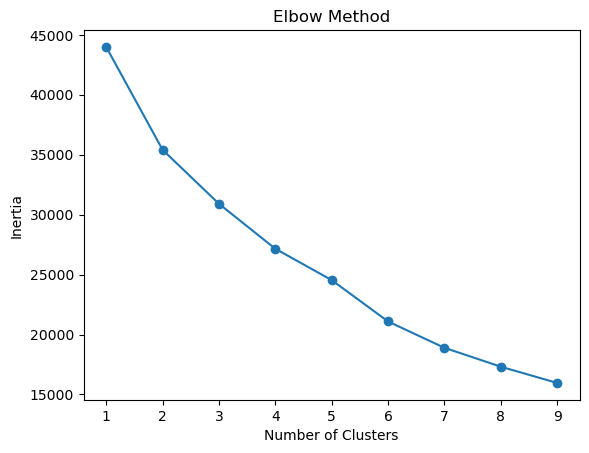

In [ ]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

The elbow point is observed at K = 3, where inertia starts decreasing slowly. Hence, we select 3 clusters.

## K-Means Clustering

K-Means groups data into K clusters by minimizing distance within clusters.

Each data point is assigned to the nearest centroid.

We choose K based on the elbow method (e.g., K=3).

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

## DBSCAN Clustering

DBSCAN is a density-based clustering algorithm.

Key advantages:
- Does not require number of clusters
- Can detect noise (outliers)

Parameters:
- eps → neighborhood radius  
- min_samples → minimum points to form cluster  

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

## Visualization

We use scatter plots to visualize clustering results.

Although data is high-dimensional, plotting first two features gives a basic idea of cluster separation.

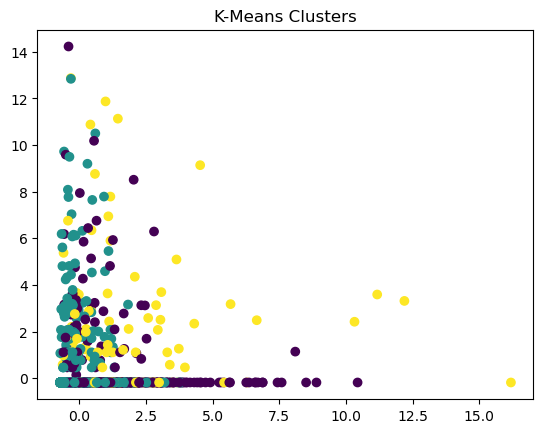

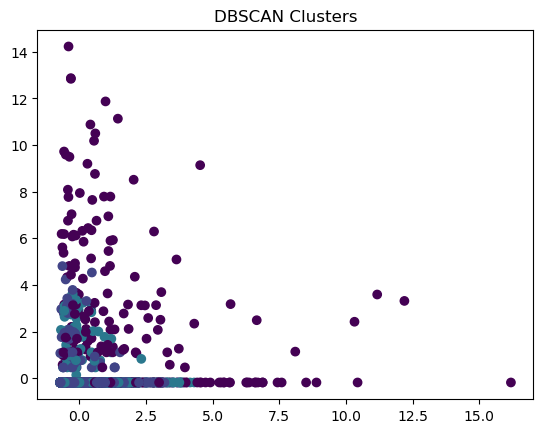

In [ ]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("K-Means Clusters")
plt.show()

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=dbscan_labels)
plt.title("DBSCAN Clusters")
plt.show()

## Evaluation

Silhouette Score measures how well clusters are formed:

- Close to 1 → well-separated clusters  
- Close to 0 → overlapping clusters  
- Negative → incorrect clustering  

Higher score indicates better clustering.

In [ ]:
print("K-Means Score:", silhouette_score(X_scaled, kmeans_labels))

if len(set(dbscan_labels)) > 1:
    print("DBSCAN Score:", silhouette_score(X_scaled, dbscan_labels))

K-Means Score: 0.31110680893107867
DBSCAN Score: 0.253747538041624


Cluster 0 represents high-value customers with high balance and activity.

Cluster 1 represents medium-level customers with moderate usage.

Cluster 2 represents low-value customers with minimal engagement.

## Model Comparison

The K-Means model achieved a silhouette score of 0.311, while DBSCAN achieved 0.254.

This indicates that K-Means performed better in forming well-defined clusters compared to DBSCAN.

K-Means works well when clusters are spherical and evenly distributed, which seems suitable for this dataset.

DBSCAN produced lower performance, likely due to parameter sensitivity and the absence of clearly dense regions in the data.

Overall, K-Means is the preferred model for this dataset.

K-Means performed better with a higher silhouette score (0.31) compared to DBSCAN (0.25).

K-Means is suitable for this dataset as clusters are evenly distributed, while DBSCAN struggled due to lack of clear density regions.

## Business Insights

Based on clustering:

- Cluster 1 → High-value customers (high balance, high activity)
- Cluster 2 → Medium customers (moderate usage)
- Cluster 3 → Low-value customers (low engagement)

These insights help in:
- Targeted marketing  
- Customer retention strategies  
- Loyalty programs  

## Handling Imbalance

In machine learning, imbalance usually refers to the situation where the target variable (labels/classes) is not evenly distributed. For example, in a classification problem, if 95% of data belongs to one class and only 5% to another, the dataset is considered imbalanced.

However, in clustering (unsupervised learning), there is **no target variable (y)**. The algorithm does not know any predefined classes — it groups data purely based on similarity or distance between data points.

Because of this, the concept of "class imbalance" does not directly apply in clustering.

That said, imbalance can still exist indirectly in the data:

- Some regions of data may be very dense (many similar data points)
- Some regions may be sparse (few data points)

This affects clustering behavior:

- K-Means tends to form clusters of similar size and may ignore small but meaningful groups
- DBSCAN, on the other hand, can handle such situations better by identifying dense regions and marking sparse points as noise

To handle such issues, we take the following steps:

1. **Feature Scaling**  
   Ensures that all features contribute equally to distance calculation. Without scaling, features with larger values dominate clustering.

2. **Algorithm Selection**  
   Choosing the right algorithm matters:
   - K-Means → works well for evenly distributed clusters
   - DBSCAN → better for uneven density and detecting outliers

3. **Parameter Tuning**  
   Adjusting parameters like:
   - Number of clusters (K in K-Means)
   - eps and min_samples (in DBSCAN)

4. **Data Understanding (EDA)**  
   Helps identify whether the dataset has dense vs sparse regions.

In conclusion, while traditional class imbalance is not present in clustering, understanding data distribution and choosing appropriate techniques ensures meaningful and balanced clustering results.

## Conclusion

In this assignment, we applied K-Means and DBSCAN to segment customers based on behavior.

K-Means provided structured clusters, while DBSCAN helped identify density-based groupings and outliers.

Feature scaling and proper selection of parameters played a crucial role in achieving meaningful clustering.

This analysis demonstrates how clustering can be used in real-world business scenarios to improve decision-making and customer targeting.